In [40]:
import numpy as np
import matplotlib.pyplot as plt
import re

Pasar a codigo Bragg

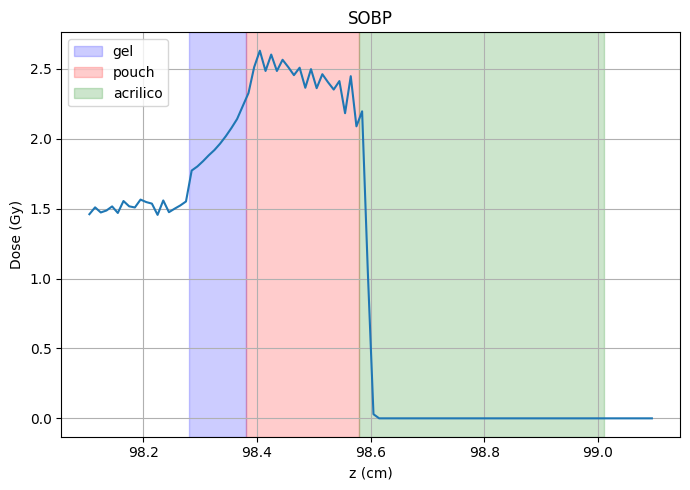

In [41]:
#DOSIS VS Z
archivo = "bragg_pouch_zcilindJesus.out"

tiempo_rad = 300

z = []
dose = []


with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()


        if len(parts) != 4:
            continue


        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue


        z.append((z1 + z2) / 2)
        dose.append(d)


plt.figure(figsize=(7,5))

plt.axvspan(98.280, 98.380, color='b', alpha=0.2, label='gel')
plt.axvspan(98.380, 98.580, color='r', alpha=0.2, label='pouch')
plt.axvspan(98.580, 99.010, color='g', alpha=0.2, label='acrilico') #cambiar los valores una vez subido el segundo acrilico

plt.legend()
plt.plot(z,np.array(dose)*300)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)") # gray 
plt.title("SOBP")
plt.grid(True)
plt.tight_layout()
plt.show()


Cantidad de rmin encontrados: 100
Cantidad de bins con dosis: 99
Advertencia: hay 1 bin(es) radial(es) sin dosis asociada.
Dosis mínima: 1.81032
Dosis máxima: 2.82996
Dosis media : 2.467677272727273
Error relativo medio: 0.04162828282828283


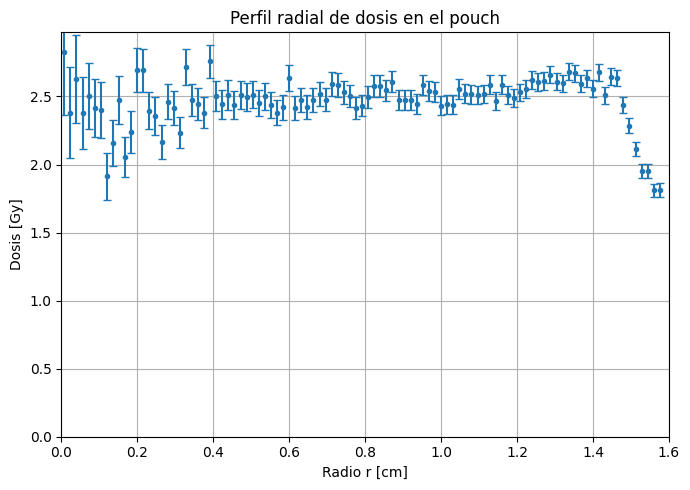

In [42]:
import numpy as np
import matplotlib.pyplot as plt

archivo = "bragg_pouch_rcilindJesus.out"

rmin = []
rmax = []
dosis = []
err_rel = []

r1_actual = None
r2_actual = None

cantidad_rmin = 0

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:

    for linea in f:

        partes = linea.split()

        if len(partes) != 4:
            continue

        # Leer radios
        if partes[0] == "rmin":
            r1_actual = float(partes[2])
            cantidad_rmin += 1

        elif partes[0] == "rmax":
            r2_actual = float(partes[2])

        # Leer línea numérica de dosis
        else:
            try:
                float(partes[0])  # zmin
                float(partes[1])  # zmax

                d = float(partes[2])
                e = float(partes[3])

                if r1_actual is not None and r2_actual is not None:
                    rmin.append(r1_actual)
                    rmax.append(r2_actual)
                    dosis.append(d)
                    err_rel.append(e)

            except ValueError:
                pass

# Convertir a arrays
rmin = np.array(rmin)
rmax = np.array(rmax)
dosis = np.array(dosis)
err_rel = np.array(err_rel)

print("Cantidad de rmin encontrados:", cantidad_rmin)
print("Cantidad de bins con dosis:", len(dosis))

if cantidad_rmin != len(dosis):
    print(
        f"Advertencia: hay {cantidad_rmin-len(dosis)} bin(es) radial(es) "
        "sin dosis asociada."
    )

if len(dosis) == 0:
    raise ValueError("No se encontró ninguna dosis en el archivo.")

# Centro de cada bin radial
r_centro = 0.5 * (rmin + rmax)

# Error absoluto
err_abs = dosis * err_rel

# Factor de conversión
factor = 300

dosis_fisica = dosis * factor
err_abs_fisica = err_abs * factor

print("Dosis mínima:", np.min(dosis_fisica))
print("Dosis máxima:", np.max(dosis_fisica))
print("Dosis media :", np.mean(dosis_fisica))
print("Error relativo medio:", np.mean(err_rel))

# Gráfico
plt.figure(figsize=(7,5))

plt.errorbar(
    r_centro,
    dosis_fisica,
    yerr=err_abs_fisica,
    fmt='.',
    capsize=3
)

plt.xlabel("Radio r [cm]")
plt.ylabel("Dosis [Gy]")
plt.title("Perfil radial de dosis en el pouch")

plt.xlim(0, 1.6)
plt.ylim(0, np.max(dosis_fisica)*1.05)

plt.grid(True)
plt.tight_layout()
plt.show()

Hasta acá

In [43]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 640
Dosis mínima: 0.0036799
Dosis máxima: 0.0098234
Primeros valores: [0.0040321 0.0042036 0.0040065 0.0038061 0.0085999 0.0085776 0.0084105
 0.0080572 0.009033  0.009572 ]


In [44]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [45]:
file_path = "histograma_dosis.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

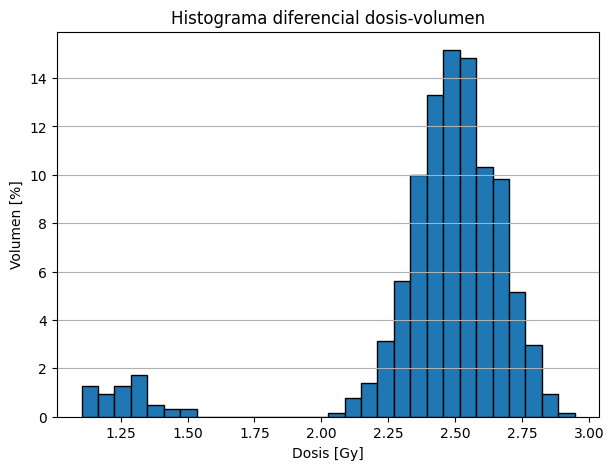

In [46]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [47]:
print(np.std(data_dosis_fisica)/np.mean(data_dosis_fisica))

0.13723937838771166


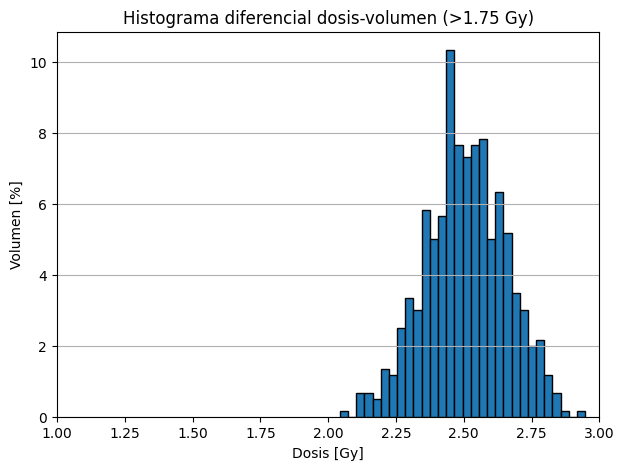

In [48]:
tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

# Crear nuevo array con dosis mayores o iguales a 1.75 Gy
dosis_filtrada = data_dosis_fisica[data_dosis_fisica >= 1.75]

n_bins = len(dosis_filtrada)

if n_bins == 0:
    raise ValueError("No hay datos de dosis mayores o iguales a 1.75 Gy.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

# Histograma diferencial
volumen_por_intervalo, bordes_dosis = np.histogram(
    dosis_filtrada,
    bins=bins_dosis,
    weights=np.ones_like(dosis_filtrada) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)
plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)
plt.xlim(1,3)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen (>1.75 Gy)")

plt.grid(True, axis="y")
plt.show()

In [49]:
print(np.std(dosis_filtrada)/np.mean(dosis_filtrada))

0.05928293013027774


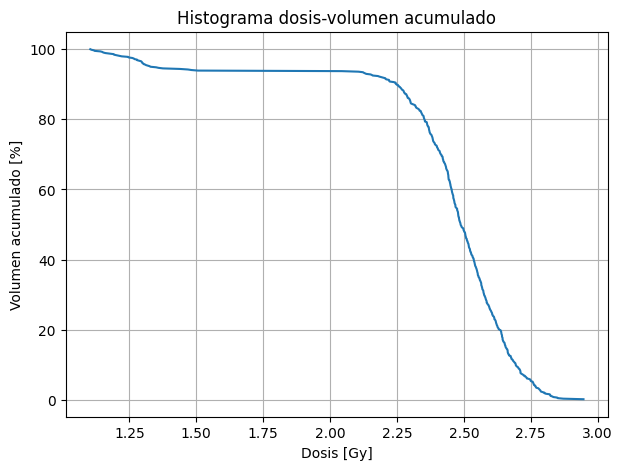

In [50]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

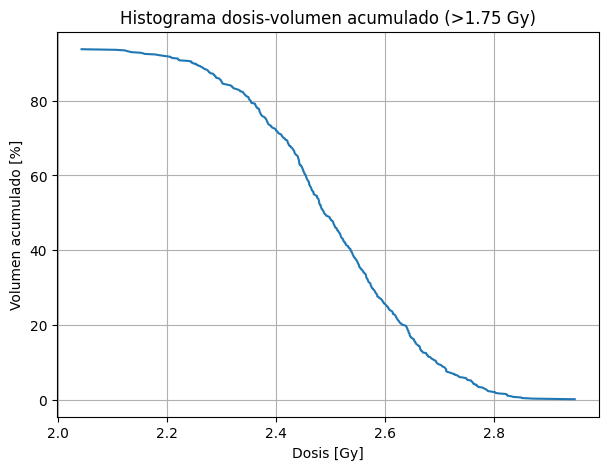

In [51]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(dosis_filtrada) * volumen_por_bin

dosis_ordenada = np.sort(dosis_filtrada)

vol_acumulado = np.array([
    np.sum(volumen_total[dosis_filtrada >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado (>1.75 Gy)")
plt.grid(True)
plt.show()

In [52]:
# ─────────────────────────────────────────────
# Índice de homogeneidad: (D2 - D98) / D2
# ─────────────────────────────────────────────

dosis_gy = dosis_ordenada * tiempo_seg  # dosis en Gy (igual que en el plot)

# Invertimos para que np.interp funcione (volumen va de 100 a 0)
vol_inv  = vol_acumulado[::-1]
dosis_inv = dosis_gy[::-1]

D2  = np.interp(2,  vol_inv, dosis_inv)
D98 = np.interp(98, vol_inv, dosis_inv)

HI = (D2 - D98) / D2

print(f"D2  = {D2:.3f} Gy")
print(f"D98 = {D98:.3f} Gy")
print(f"HI  = {HI:.4f}")


D2  = 840.319 Gy
D98 = 613.071 Gy
HI  = 0.2704


Este grafico nos dice qué porcentaje del volumen recibió una dosis mayor o igual que cierto valor :

Por ejemplo:

Dosis ≥ 0.010 Gy/source → 100% del volumen

Dosis ≥ 0.012 Gy/source → 80% del volumen

Dosis ≥ 0.014 Gy/source → 45% del volumen

Dosis ≥ 0.016 Gy/source → 20% del volumen

In [53]:
nx = 16
ny = 10
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 640
Valores leídos: 640
Todo ok: se leyeron todos los bins.


Filas totales leídas : 640
Shape               : (640, 4)

Capa z=1 → z ∈ [98.4800, 98.5300] cm
Vóxeles en la capa : 160
Dosis mín : 1.1170e+00 Gy
Dosis máx : 2.7818e+00 Gy
Dosis prom : 2.4200e+00 Gy


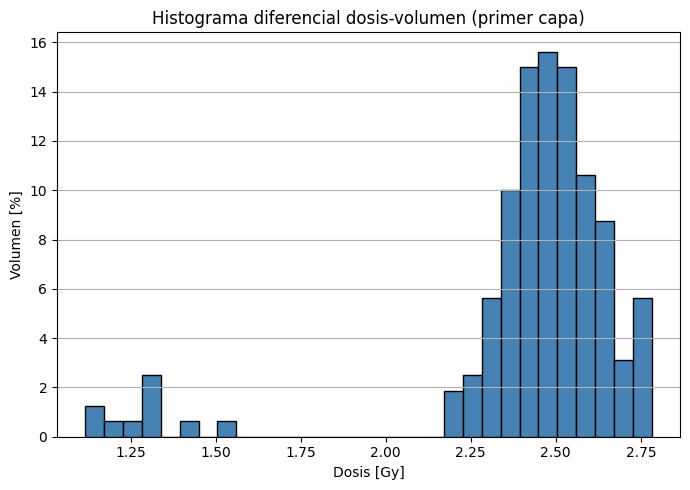

In [54]:
# ── Parámetros del tally ──────────────────────────────────────────
NX, NY, NZ = 16, 10, 4
CAPA_Z = 2          # 0-indexado → 1 = segunda capa

# ── Lector ───────────────────────────────────────────────────────
def leer_dosis_phits_tdeposit(filename):
    filas = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if (linea.startswith("#") or linea.startswith("'") or
                        linea.startswith("ms") or linea.startswith("wt") or
                        linea.startswith("\\") or linea.startswith("e:")):
                    leyendo_tabla = False
                    continue

                partes = linea.split()
                if len(partes) == 4:
                    try:
                        filas.append([float(p) for p in partes])
                    except ValueError:
                        pass

    return np.array(filas)   # shape: (NX*NY*NZ, 4) → columnas: z_low z_up dose rerr


# ── Lectura ───────────────────────────────────────────────────────
file_path = "histograma_dosis.out"
tabla = leer_dosis_phits_tdeposit(file_path)

print(f"Filas totales leídas : {len(tabla)}")
print(f"Shape               : {tabla.shape}")

# ── Extraer SÓLO la segunda capa en Z ────────────────────────────
# PHITS organiza con z como índice más interno (x → y → z)
# → los vóxeles de z=1 están en filas 1, 5, 9, ... (cada NZ filas)
indices_capa2 = np.arange(CAPA_Z, NX * NY * NZ, NZ)
capa2 = tabla[indices_capa2]          # shape (160, 4)

z_low = capa2[0, 0]
z_up  = capa2[0, 1]
print(f"\nCapa z=1 → z ∈ [{z_low:.4f}, {z_up:.4f}] cm")
print(f"Vóxeles en la capa : {len(capa2)}")   # debe dar 160

# ── Dosis física ──────────────────────────────────────────────────
tiempo_seg = 300
dosis_fisica = capa2[:, 2] * tiempo_seg   # columna 2 = dose


print(f"Dosis mín : {dosis_fisica.min():.4e} Gy")
print(f"Dosis máx : {dosis_fisica.max():.4e} Gy")
print(f"Dosis prom : {dosis_fisica.mean():.4e} Gy")

# ── DVH diferencial ───────────────────────────────────────────────
n_voxeles  = len(dosis_fisica)
vol_voxel  = 100.0 / n_voxeles           # % por vóxel

bins_dosis = 30

vol_por_intervalo, bordes = np.histogram(
    dosis_fisica,
    bins=bins_dosis,
    weights=np.ones(n_voxeles) * vol_voxel
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos  = np.diff(bordes)

plt.figure(figsize=(7, 5))
plt.bar(centros, vol_por_intervalo, width=anchos,
        align="center", edgecolor="black", color="steelblue")

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen (primer capa)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()



In [55]:
print(np.std(dosis_fisica)/np.mean(dosis_fisica))

0.13175085849684107


Filas totales leídas : 640
Shape               : (640, 4)

Capa z=1 → z ∈ [98.5300, 98.5800] cm
Vóxeles en la capa : 160
Dosis mín : 2.0436e+00 Gy
Dosis máx : 2.7859e+00 Gy


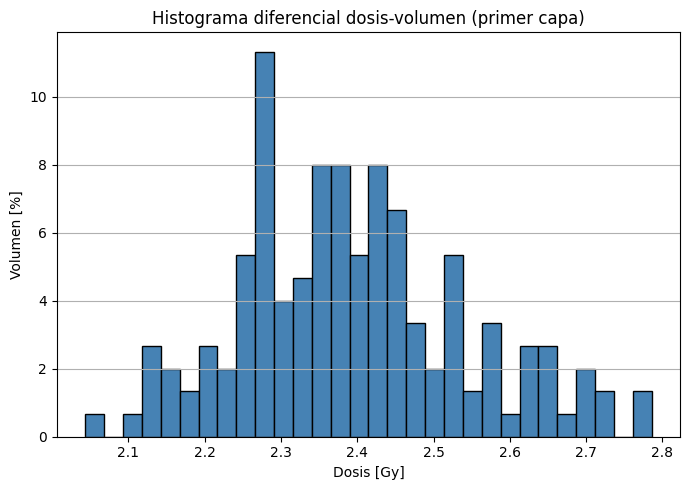

In [56]:
#VEO HISTOGRAMA POR CAPAS A PARTIR DE DATOS FILTRADOS (DEL PLOT SACO LA PRIMER PARTE)
# ── Parámetros del tally ──────────────────────────────────────────
NX, NY, NZ = 16, 10, 4
CAPA_Z = 3          # 0-indexado → 1 = segunda capa

# ── Lector ───────────────────────────────────────────────────────
def leer_dosis_phits_tdeposit(filename):
    filas = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if (linea.startswith("#") or linea.startswith("'") or
                        linea.startswith("ms") or linea.startswith("wt") or
                        linea.startswith("\\") or linea.startswith("e:")):
                    leyendo_tabla = False
                    continue

                partes = linea.split()
                if len(partes) == 4:
                    try:
                        filas.append([float(p) for p in partes])
                    except ValueError:
                        pass

    return np.array(filas)   # shape: (NX*NY*NZ, 4) → columnas: z_low z_up dose rerr


# ── Lectura ───────────────────────────────────────────────────────
file_path = "histograma_dosis.out"
tabla = leer_dosis_phits_tdeposit(file_path)

print(f"Filas totales leídas : {len(tabla)}")
print(f"Shape               : {tabla.shape}")

# ── Extraer SÓLO la segunda capa en Z ────────────────────────────
# PHITS organiza con z como índice más interno (x → y → z)
# → los vóxeles de z=1 están en filas 1, 5, 9, ... (cada NZ filas)
indices_capa2 = np.arange(CAPA_Z, NX * NY * NZ, NZ)
capa2 = tabla[indices_capa2]          # shape (160, 4)

z_low = capa2[0, 0]
z_up  = capa2[0, 1]
print(f"\nCapa z=1 → z ∈ [{z_low:.4f}, {z_up:.4f}] cm")
print(f"Vóxeles en la capa : {len(capa2)}")   # debe dar 160

# ── Dosis física ──────────────────────────────────────────────────
tiempo_seg = 300
dosis_fisica = capa2[:, 2] * tiempo_seg   # columna 2 = dose
dosis_fisica = dosis_fisica[dosis_fisica >= 1.75]


print(f"Dosis mín : {dosis_fisica.min():.4e} Gy")
print(f"Dosis máx : {dosis_fisica.max():.4e} Gy")

# ── DVH diferencial ───────────────────────────────────────────────
n_voxeles  = len(dosis_fisica)
vol_voxel  = 100.0 / n_voxeles           # % por vóxel

bins_dosis = 30

vol_por_intervalo, bordes = np.histogram(
    dosis_fisica,
    bins=bins_dosis,
    weights=np.ones(n_voxeles) * vol_voxel
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos  = np.diff(bordes)

plt.figure(figsize=(7, 5))
plt.bar(centros, vol_por_intervalo, width=anchos,
        align="center", edgecolor="black", color="steelblue")

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen (primer capa)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


In [57]:
print(np.std(dosis_fisica) / np.mean(dosis_fisica))

0.062032506088547525


SACO EL GEL

In [58]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\basil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [60]:
archivo = "histograma_dosis.out"

nx = 10
ny = 16
nz = 4

xmin, xmax = -1.0, 1.0
ymin, ymax = -1.6, 1.6
zmin, zmax = 98.115, 98.315

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

In [61]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0

zmin_pouch = 98.115
zmax_pouch = 98.315
z0 = 0.5 * (zmin_pouch + zmax_pouch)

rx = 1.0
ry = 1.6
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin_pouch) & (Z <= zmax_pouch)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

In [62]:
print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 300

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica))

datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    dosis[ix, iy, iz] * tiempo_seg,
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.14 98.19 98.24 98.29]
Máscara pouch en la primera capa z:
[[False False False False False  True  True  True  True  True  True False
  False False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False False Fals

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,6,1,-0.9,-0.5,98.14,0.008228,2.46837,0.0416
1,1,6,2,-0.9,-0.5,98.19,0.008264,2.47929,0.0433
2,1,6,3,-0.9,-0.5,98.24,0.007897,2.36922,0.0468
3,1,6,4,-0.9,-0.5,98.29,0.007483,2.24496,0.0533
4,1,7,1,-0.9,-0.3,98.14,0.008618,2.58525,0.0409


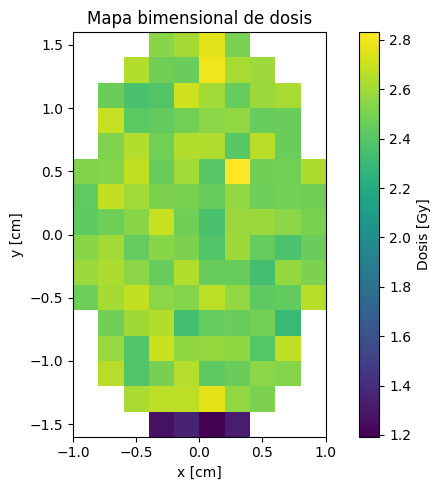

In [63]:
iz = 0

plt.figure(figsize=(7, 5))
tiempo_seg = 300

dosis_sin_aire_fisica = dosis_sin_aire * tiempo_seg

plt.imshow(
    dosis_sin_aire_fisica[:, :, iz].T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="equal"
)

plt.colorbar(label="Dosis [Gy]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title(f"Mapa bimensional de dosis")
plt.tight_layout()
plt.show()

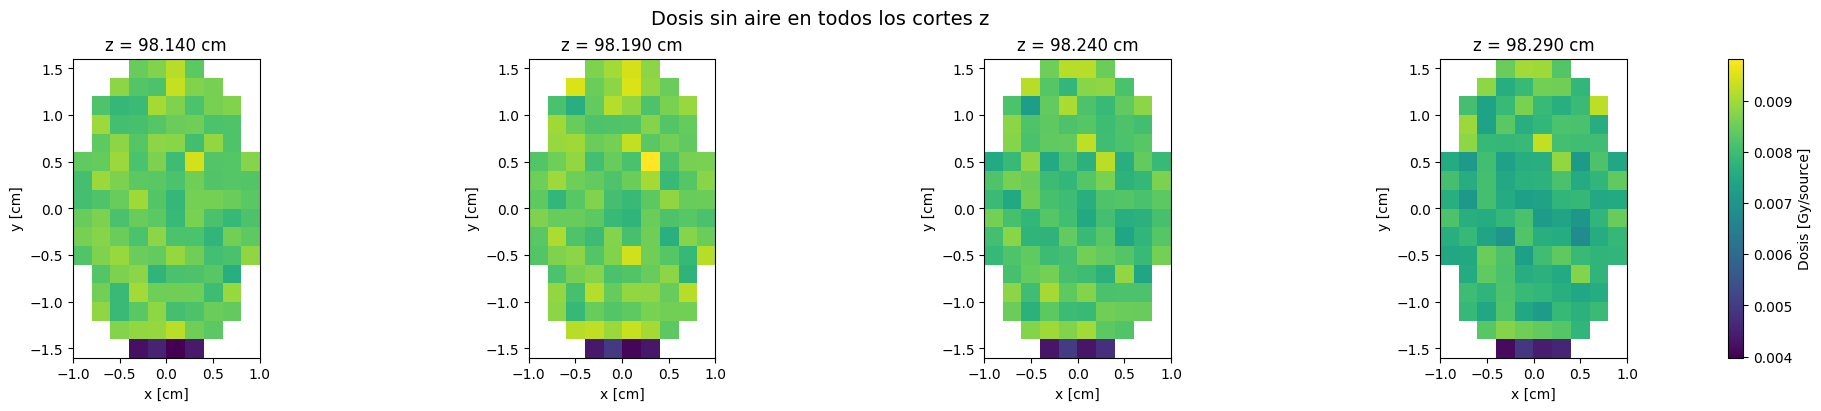

In [64]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

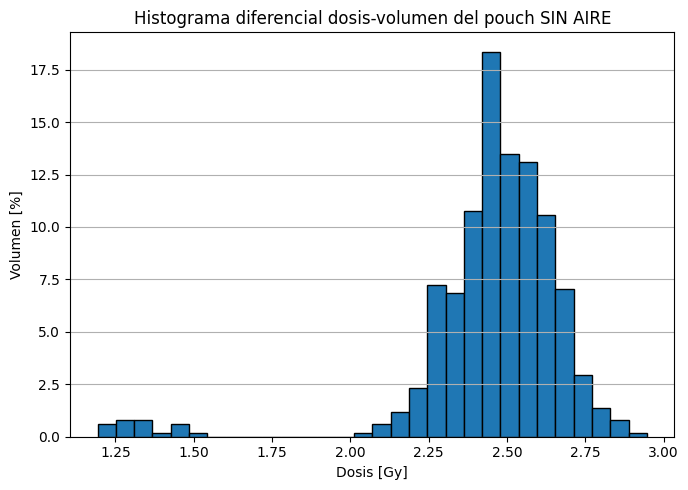

In [65]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles dentro del pouch. Revisá la máscara y los límites de z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch SIN AIRE")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [66]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 10.05%
